# Volatility Forecasting — Weekly Silver Realised Volatility

The other weekly notebooks all target the **weekly silver log-return**. Across ARIMA,
VAR, MIDAS, RF, XGBoost, and LSTM, the best WDA we have squeezed out is ≈ 0.59–0.62 on
test — roughly 60 % directional accuracy, with the simplest models often within
striking distance of the best. Return predictability for silver is, at best, weak.

**The question this chapter asks:** is **volatility** easier to forecast than direction?

Volatility clustering (Mandelbrot 1963; Engle 1982) is one of the most robust stylised
facts in financial time series — high-vol weeks cluster, low-vol weeks cluster. So even
when returns look like white noise, squared returns carry strong autocorrelation and
are forecastable. If silver vol is forecastable, that is a thesis-relevant finding (vol
forecasts feed risk management, option pricing, position sizing) even when returns are
not.

**Target** — weekly realised volatility from daily returns:

$$\text{RV}_t = \sqrt{\sum_{i \in \text{week } t} r_i^2}$$

### Notebook layout

This chapter is split the same way as the `weekly/` return notebooks — one shared
feature-build notebook, then one notebook per model, then an evaluation notebook:

| Notebook | Contents |
|---|---|
| `00_features.ipynb` (this one) | Load daily data, aggregate to weekly RV, EDA, build the HAR + EXOG feature frame, split → `volatility_weekly.csv` |
| `01_har.ipynb` | Naïve floor + HAR-RV (Corsi 2009) |
| `02_garch.ipynb` | GARCH(1,1) walk-forward |
| `03_random_forest.ipynb` | Random Forest on HAR + EXOG |
| `04_xgboost.ipynb` | XGBoost on HAR + EXOG |
| `evaluation.ipynb` | Cross-model table, sub-period breakdown, 2026 zoom, DM tests |

Every model notebook loads the single `volatility_weekly.csv` produced here, so the RV
target and feature definitions are guaranteed identical across models.

**Metrics** (defined in `src/vol_utils.py`): RMSE, MAE, $R^2$, and **DCA** —
Direction-of-Change Accuracy on $\Delta \log \text{RV}$, i.e. did the model correctly
call vol rising vs falling. DA/WDA from the return notebooks do not apply because
RV ≥ 0.


## Setup


In [38]:
import sys, os
sys.path.append(os.path.abspath('../../src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf
import warnings; warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
plt.rcParams['figure.figsize'] = (10, 4)


## 1. Load daily data and aggregate to weekly RV

Same `train.csv / val.csv / test.csv` as every other weekly notebook. For each asset
the daily returns are squared, summed within each W-FRI week, then square-rooted to
give weekly realised volatility.

**Why square daily returns and sum, rather than averaging daily volatilities?**
Realised *variance* is additive — the variance contribution of each day adds up over
the week — whereas volatility (a standard deviation) is not. So we sum daily squared
returns to get the weekly realised *variance*, and take the square root only at the
end to recover weekly realised *volatility*. Summing daily volatilities directly would
have no clean statistical meaning.

In [39]:
train = pd.read_csv('../../data/processed/train.csv', parse_dates=['Date']).set_index('Date')
val   = pd.read_csv('../../data/processed/val.csv',   parse_dates=['Date']).set_index('Date')
test  = pd.read_csv('../../data/processed/test.csv',  parse_dates=['Date']).set_index('Date')

ASSETS = ['silver_return', 'gold_return', 'copper_return', 'usd_return',
          'sp500_return', 'vix_return', 'oil_return']

daily = pd.concat([train[ASSETS], val[ASSETS], test[ASSETS]]).sort_index()

def weekly_rv(daily_rets):
    """Weekly realised volatility = sqrt of the summed daily squared returns."""
    return np.sqrt((daily_rets ** 2).resample('W-FRI').sum())

rv = pd.concat({a.replace('_return', '_rv'): weekly_rv(daily[a]) for a in ASSETS}, axis=1)
rv = rv.dropna()
print(f'Weekly RV obs: {len(rv)}  ({rv.index.min().date()} -> {rv.index.max().date()})')
rv.head()


Weekly RV obs: 592  (2015-01-09 -> 2026-05-08)


,silver_rv,gold_rv,copper_rv,usd_rv,sp500_rv,vix_rv,oil_rv
Date,,,,,,,
2015-01-09,0.039710,0.021906,0.018301,0.008919,0.030649,0.203221,0.069482
2015-01-16,0.054048,0.029461,0.064370,0.004825,0.019257,0.150161,0.101212
2015-01-23,0.019898,0.015792,0.029085,0.017460,0.016872,0.158786,0.066598
2015-01-30,0.081585,0.034358,0.041376,0.010309,0.025178,0.254896,0.092746
2015-02-06,0.032449,0.026310,0.035942,0.013249,0.022479,0.172626,0.125761


## 2. EDA — getting a picture of the target

Five diagnostics on weekly silver realised volatility, each motivating a downstream
modelling or evaluation choice elsewhere in the chapter:

| § | Diagnostic | Downstream choice it motivates |
|---|---|---|
| 2.1 | RV time series with regime markers | sub-period breakdown in `evaluation.ipynb`; visual context for the 2020 / 2021 / 2026 spikes |
| 2.2 | Distribution + QQ plot vs Normal | QLIKE as the proxy-robust DM loss — squared-error DM is dominated by the right tail |
| 2.3 | ACF of RV vs returns | HAR mixture-of-horizons construction in §3 (predictable second moment, unpredictable first) |
| 2.4 | Contemporaneous correlation heatmap (silver RV + 6 EXOG + 3 sentiment) | Co-movement among all candidate features; previews the multicollinearity that hurts `HAR+EXOG` and the combined-sentiment rung in `01_har` §5 |
| 2.5 | Lagged predictive correlation (predictors at $t{-}1$, silver RV at $t$) | Lead-lag correlation that drives HAR-X marginal predictive power — distinguishes predictive signal from contemporaneous co-movement |

**A note on squared returns as a variance proxy.** By definition

$$\mathbb{E}[r_t^2] = \operatorname{Var}(r_t) + \big(\mathbb{E}[r_t]\big)^2,$$

so a squared return measures variance *plus* the squared mean. At daily and weekly
horizons the conditional mean of financial returns is very close to zero, so
$\mathbb{E}[r_t] \approx 0$ and therefore
$\mathbb{E}[r_t^2] \approx \operatorname{Var}(r_t)$. Using summed squared returns as
realised variance is standard precisely under this assumption — at these frequencies
volatility dominates the mean.

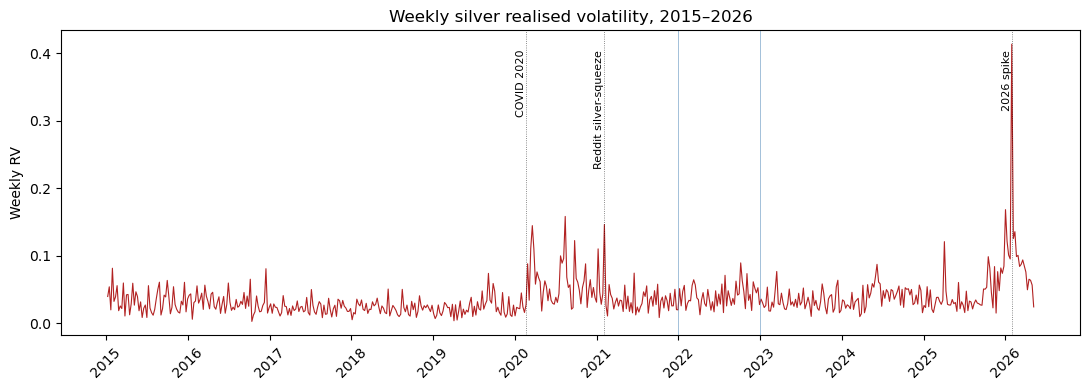

silver_rv: min=0.0028  median=0.0295  mean=0.0368  max=0.4136   max/median = 14.0x


In [40]:
import matplotlib.dates as mdates

# 2.1 -- Weekly silver RV across the full sample, with regime markers and split lines.
# The annotated weeks are the spikes that show up in the per-year breakdown in
# `evaluation.ipynb`; vertical blue lines mark the train | val | test boundaries.

fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(rv.index, rv['silver_rv'], color='firebrick', lw=0.8)
ax.set_title('Weekly silver realised volatility, 2015–2026')
ax.set_ylabel('Weekly RV')

# Show every year on x-axis
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.tick_params(axis='x', rotation=45)

ymax = rv['silver_rv'].max()

episodes = [
    (pd.Timestamp('2020-02-20'), 'COVID 2020'),
    (pd.Timestamp('2021-02-05'), 'Reddit silver-squeeze'),
    (rv.loc['2026']['silver_rv'].idxmax(), '2026 spike'),
]

for dt, lbl in episodes:
    ax.axvline(dt, color='black', ls=':', lw=0.6, alpha=0.6)
    ax.text(dt, ymax * 0.98, lbl, fontsize=8, ha='right', rotation=90, va='top')

for dt in ['2021-12-31', '2022-12-31']:
    ax.axvline(pd.Timestamp(dt), color='steelblue', lw=0.5, alpha=0.7)

plt.tight_layout()
plt.show()

print(f"silver_rv: min={rv['silver_rv'].min():.4f}  "
      f"median={rv['silver_rv'].median():.4f}  "
      f"mean={rv['silver_rv'].mean():.4f}  "
      f"max={rv['silver_rv'].max():.4f}   "
      f"max/median = {rv['silver_rv'].max()/rv['silver_rv'].median():.1f}x")

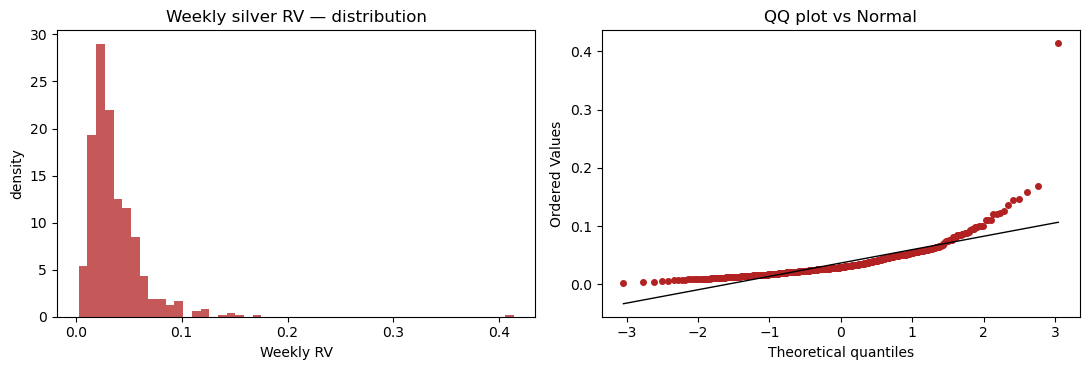

skewness        = +5.28   (Normal has 0)
excess kurtosis = +57.89   (Normal has 0)
95th pct = 0.0841   99th pct = 0.1265   max = 0.4136


In [41]:
# 2.2 -- Distribution of weekly silver RV (right-skewed, heavy upper tail) and the
# QQ plot vs Normal. The right-tail departure is what kills squared-error DM power
# in `evaluation.ipynb` §4 -- a handful of upper-tail weeks dominate the loss
# differential -- and is why QLIKE (Patton 2011) is the primary DM loss. (See the
# markdown cell after this one for how to read the QQ plot.)
from scipy import stats as scipy_stats

silver = rv['silver_rv'].dropna()
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))

ax[0].hist(silver, bins=50, color='firebrick', alpha=0.75, density=True)
ax[0].set_title('Weekly silver RV — distribution')
ax[0].set_xlabel('Weekly RV'); ax[0].set_ylabel('density')

scipy_stats.probplot(silver, dist='norm', plot=ax[1])
ax[1].set_title('QQ plot vs Normal')
ax[1].get_lines()[0].set_markerfacecolor('firebrick')
ax[1].get_lines()[0].set_markeredgecolor('firebrick')
ax[1].get_lines()[0].set_markersize(4)
ax[1].get_lines()[1].set_color('black'); ax[1].get_lines()[1].set_linewidth(1)

plt.tight_layout(); plt.show()

print(f'skewness        = {silver.skew():+.2f}   (Normal has 0)')
print(f'excess kurtosis = {silver.kurtosis():+.2f}   (Normal has 0)')
print(f'95th pct = {silver.quantile(0.95):.4f}   '
      f'99th pct = {silver.quantile(0.99):.4f}   '
      f'max = {silver.max():.4f}')

**How to read the QQ plot above.** The Normal reference line passes through the bulk
of the points; the upper-tail points curve sharply *above* the line. That curvature is
the diagnostic — silver-RV's upper tail is much fatter than a Normal of the same
mean/variance would produce. Those extreme weeks are not "rare normal events"; they
are categorically more extreme than Gaussian sampling allows (excess kurtosis ≈ +58
above; Normal has 0).

This is exactly the property that destroys squared-error DM power in `evaluation.ipynb`
§4: a handful of upper-tail weeks carry squared errors orders of magnitude larger than
the rest, so they dominate the loss differential and inflate the DM variance even when
a model is steadily better on the typical weeks. QLIKE's log-ratio form down-weights
that tail and recovers the power MSE loses.

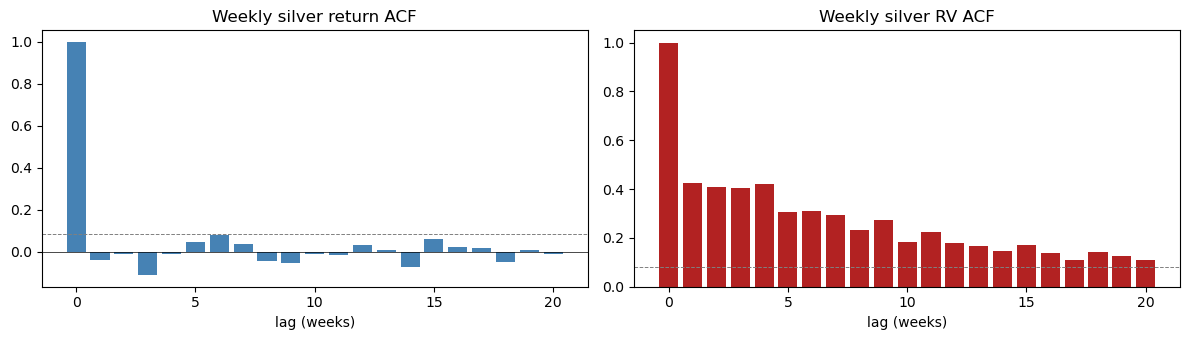

Return  ACF(1) = -0.041
RV      ACF(1) = +0.426
RV      ACF(4) = +0.422   <- multi-week persistence


In [42]:
silver_w_ret = daily['silver_return'].resample('W-FRI').sum().reindex(rv.index)
silver_rv    = rv['silver_rv']

n_lags = 20
acf_ret = acf(silver_w_ret.dropna(), nlags=n_lags, fft=True)
acf_rv  = acf(silver_rv.dropna(),    nlags=n_lags, fft=True)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
ax[0].bar(range(len(acf_ret)), acf_ret, color='steelblue'); ax[0].set_title('Weekly silver return ACF'); ax[0].axhline(0, color='k', lw=0.5)
ax[1].bar(range(len(acf_rv)),  acf_rv,  color='firebrick'); ax[1].set_title('Weekly silver RV ACF');     ax[1].axhline(0, color='k', lw=0.5)
for a in ax: a.set_xlabel('lag (weeks)'); a.axhline(2/np.sqrt(len(silver_rv)), color='grey', ls='--', lw=0.7)
plt.tight_layout(); plt.show()

print(f'Return  ACF(1) = {acf_ret[1]:+.3f}')
print(f'RV      ACF(1) = {acf_rv[1]:+.3f}')
print(f'RV      ACF(4) = {acf_rv[4]:+.3f}   <- multi-week persistence')


Alternatively we can plot like so

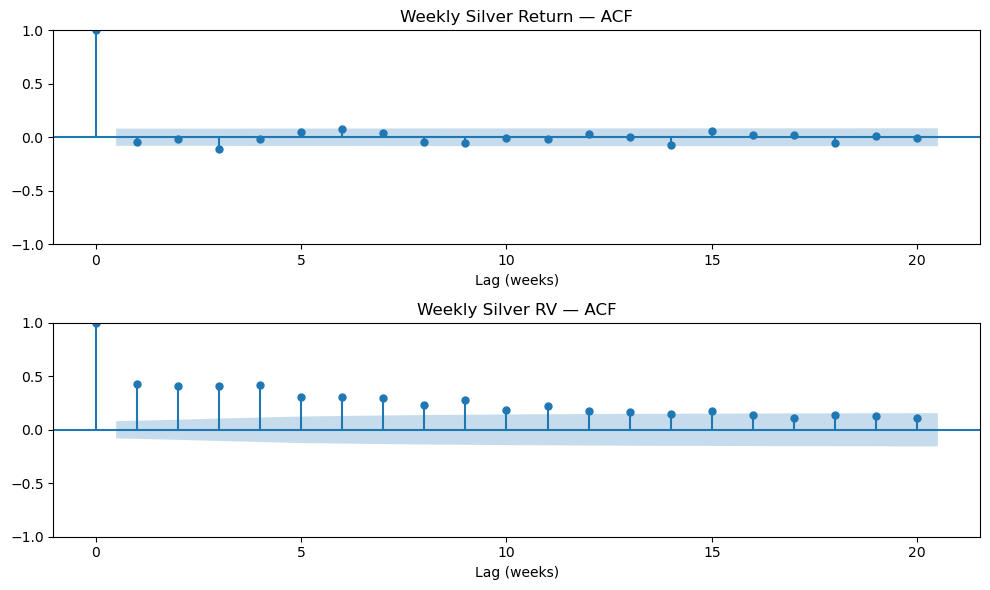

In [43]:
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

plot_acf(silver_w_ret.dropna(), ax=axes[0], lags=n_lags, title='Weekly Silver Return — ACF')
plot_acf(silver_rv.dropna(),    ax=axes[1], lags=n_lags, title='Weekly Silver RV — ACF')

for ax in axes:
    ax.set_xlabel('Lag (weeks)')

plt.tight_layout()
plt.show()

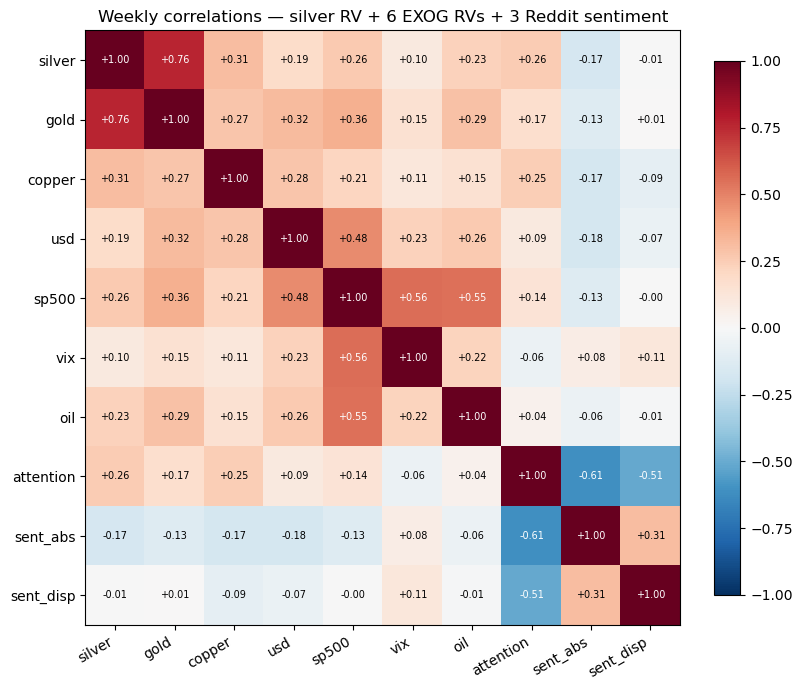

silver_rv correlation with each predictor (sorted by |r|):
gold_rv             0.758
copper_rv           0.306
sp500_rv            0.260
reddit_attention    0.258
oil_rv              0.228
usd_rv              0.185
reddit_sent_abs    -0.165
vix_rv              0.097
reddit_sent_disp   -0.006

strongest internal pair (by |corr|): reddit_attention <-> reddit_sent_abs = -0.612


In [44]:
# 2.4 -- Contemporaneous pairwise correlations across the 7 weekly RVs (silver +
# 6 EXOG) and the 3 Reddit sentiment features. Two readings: (a) silver_rv
# co-movement with each EXOG-RV and sentiment series -- motivating evidence for the
# EXOG cross-asset rung and sentiment ablation in 01_har / 03 / 04; (b) internal
# correlations within EXOG and within sentiment -- the multicollinearity that
# predicts the HAR+EXOG and combined-sentiment underperformance in 01_har §5.
#
# Sentiment is reconstructed locally with underscore-prefixed names so it does not
# leak into the formal feature build in §3 / §5 (and is reused by §2.5 below).
_sent_daily = pd.read_csv('../../data/processed/daily_sentiment.csv',
                          parse_dates=['date']).set_index('date')
_sg = _sent_daily.resample('W-FRI')
_sent_w = pd.DataFrame({
    'reddit_attention': np.log1p(_sg['reddit_post_count'].sum()),
    'reddit_sent_abs' : _sg['reddit_sentiment'].mean().abs(),
    'reddit_sent_disp': _sg['reddit_sentiment'].std(),
})

_combined = pd.concat([rv, _sent_w], axis=1).dropna()
corr = _combined.corr()

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r')
labels = [c.replace('_rv', '').replace('reddit_', '') for c in corr.columns]
ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=30, ha='right'); ax.set_yticklabels(labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f'{corr.iloc[i, j]:+.2f}', ha='center', va='center',
                color='white' if abs(corr.iloc[i, j]) > 0.5 else 'black', fontsize=7)
ax.set_title('Weekly correlations — silver RV + 6 EXOG RVs + 3 Reddit sentiment')
fig.colorbar(im, ax=ax, fraction=0.04)
plt.tight_layout(); plt.show()

print('silver_rv correlation with each predictor (sorted by |r|):')
_sc = corr['silver_rv'].drop('silver_rv')
print(_sc.reindex(_sc.abs().sort_values(ascending=False).index).round(3).to_string())

# strongest internal pair (excluding silver, by |corr|)
_others = corr.drop(index='silver_rv', columns='silver_rv')
_off_diag = _others.where(~np.eye(len(_others), dtype=bool))
_pair = _off_diag.abs().stack().idxmax()
print(f"\nstrongest internal pair (by |corr|): "
      f"{_pair[0]} <-> {_pair[1]} = {_others.loc[_pair[0], _pair[1]]:+.3f}")

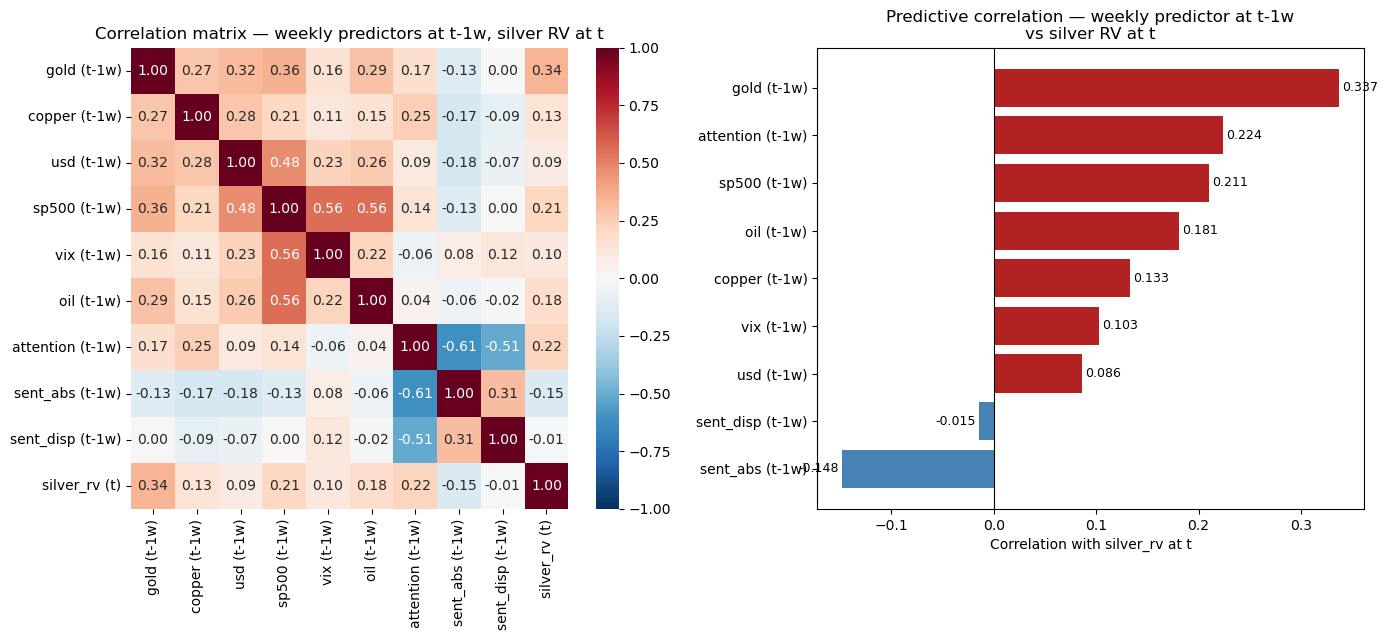

1-week predictive correlations with silver_rv at t (predictors at t-1w):
sent_abs (t-1w)    -0.148114
sent_disp (t-1w)   -0.014504
usd (t-1w)          0.085827
vix (t-1w)          0.103097
copper (t-1w)       0.133287
oil (t-1w)          0.180830
sp500 (t-1w)        0.210566
attention (t-1w)    0.224357
gold (t-1w)         0.337009


In [45]:
# 2.5 -- Predictive correlations: each candidate predictor lagged 1 week vs the
# silver-RV target at time t. Two views: (left) the full correlation matrix among
# lagged predictors and the target; (right) the sorted bar chart of the
# predictor -> silver_rv(t) row alone, the single most useful EDA for HAR-X model
# selection. Mirrors the analogous lagged-correlation cell in the returns chapter
# (notebooks/02_features.ipynb).
#
# Lead-lag correlations are *much* smaller than the contemporaneous ones in §2.4 --
# co-movement is not the same as predictive power.
#
# Colormap (RdBu_r) and feature ordering deliberately match §2.4 and §5b so the
# three heatmaps in this notebook are read with the same visual conventions.
import seaborn as sns

_exog_lag = rv.drop(columns='silver_rv').shift(1).rename(
    columns=lambda c: c.replace('_rv', '') + ' (t-1w)')
_sent_lag = _sent_w.shift(1).rename(
    columns=lambda c: c.replace('reddit_', '') + ' (t-1w)')

_lagged = pd.concat([_exog_lag, _sent_lag], axis=1)
_lagged['silver_rv (t)'] = rv['silver_rv']            # target always last column
_lag_corr = _lagged.dropna().corr()

predictors = [c for c in _lag_corr.columns if c != 'silver_rv (t)']
lag_row = _lag_corr.loc[predictors, 'silver_rv (t)'].sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, max(6, len(predictors) * 0.5 + 2)))

# Match §2.4 / §5b: RdBu_r diverging colormap, white at 0, symmetric range.
sns.heatmap(_lag_corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Correlation matrix — weekly predictors at t-1w, silver RV at t')

# Bar-chart colours follow the heatmap convention: blue = negative, red = positive.
colors = ['steelblue' if v < 0 else 'firebrick' for v in lag_row.values]
axes[1].barh(lag_row.index, lag_row.values, color=colors)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_xlabel('Correlation with silver_rv at t')
axes[1].set_title('Predictive correlation — weekly predictor at t-1w\nvs silver RV at t')
for v, name in zip(lag_row.values, lag_row.index):
    axes[1].text(v + 0.003 * (1 if v >= 0 else -1), name, f'{v:.3f}',
                 va='center', ha='left' if v >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

print('1-week predictive correlations with silver_rv at t (predictors at t-1w):')
print(lag_row.to_string())

## 3. HAR features + EXOG cross-asset RVs

The model-specific notebooks all draw from the same feature frame built here.

**HAR features.** The HAR-RV model (Corsi 2009 — see `01_har.ipynb` for the full model
description) regresses RV on trailing averages over several horizons. The name is short
for the *Heterogeneous Autoregressive* model of realised volatility: it assumes market
participants act on different time horizons — short-term traders react to last week,
medium-term traders to last month, longer-term traders to last quarter — so the
volatility observed today reflects all of those horizons at once. For the **weekly**
target we build three trailing averages of past RV:

- $\text{RV}^{(w)}_{t-1}$ — last week's RV (short horizon)
- $\text{RV}^{(m)}_{t-1}$ — 4-week trailing mean (≈ 1 month, medium horizon)
- $\text{RV}^{(q)}_{t-1}$ — 12-week trailing mean (≈ 1 quarter, long horizon)

All three apply `.shift(1)` first, so only information available at the end of week
$t-1$ enters the week-$t$ prediction — no intra-week look-ahead.

**EXOG features.** The tree models (`03`, `04`) additionally get 1-week lags of the
cross-asset RVs — gold, copper, USD, S&P 500, VIX, oil — to test whether volatility
spills over across asset classes. HAR-RV and GARCH stay univariate.


In [46]:
def har_features(rv_series):
    """Three HAR trailing averages of past RV (short / medium / long horizon), all lagged 1 week."""
    df = pd.DataFrame(index=rv_series.index)
    df['rv_w_lag1'] = rv_series.shift(1)
    df['rv_m_lag1'] = rv_series.shift(1).rolling(4).mean()
    df['rv_q_lag1'] = rv_series.shift(1).rolling(12).mean()
    return df

har = har_features(rv['silver_rv'])

# EXOG: 1-week lag of each cross-asset RV
exog_vol = pd.DataFrame(index=rv.index)
for c in rv.columns:
    if c == 'silver_rv':
        continue
    exog_vol[c.replace('_rv', '_rv_lag1')] = rv[c].shift(1)

# silver_ret = weekly silver log-return, kept for the GARCH notebook (it models returns, not RV)
frame = pd.concat([rv[['silver_rv']].rename(columns={'silver_rv': 'target'}),
                   har, exog_vol,
                   silver_w_ret.rename('silver_ret')], axis=1).dropna()
print(f'Modelling frame: {len(frame)} obs, {frame.shape[1]-1} columns besides target')
frame.head()


Modelling frame: 580 obs, 10 columns besides target


,target,rv_w_lag1,rv_m_lag1,rv_q_lag1,gold_rv_lag1,copper_rv_lag1,usd_rv_lag1,sp500_rv_lag1,vix_rv_lag1,oil_rv_lag1,silver_ret
Date,,,,,,,,,,,
2015-04-03,0.042182,0.010778,0.029519,0.038292,0.010026,0.021660,0.010662,0.016350,0.140043,0.084681,-0.021697
2015-04-10,0.042694,0.042182,0.033638,0.038498,0.025166,0.015996,0.011257,0.015943,0.072036,0.059034,-0.019120
2015-04-17,0.012582,0.042694,0.038844,0.037551,0.021050,0.020324,0.014129,0.010077,0.095041,0.098479,-0.009144
2015-04-24,0.028814,0.012582,0.027059,0.036942,0.011268,0.022176,0.012719,0.013421,0.157165,0.065134,-0.037051
2015-05-01,0.059376,0.028814,0.031568,0.032544,0.024591,0.033291,0.009486,0.011093,0.064794,0.040856,0.030246


### Which model uses which column

`frame` is the single source every volatility notebook draws from — each model then
picks its own subset of these columns:

| Column(s) | HAR-RV (`01`) | GARCH (`02`) | RF (`03`) | XGB (`04`) | Naïve (`01`) |
|---|:--:|:--:|:--:|:--:|:--:|
| `target` (silver RV) | predicted | predicted | predicted | predicted | predicted |
| `rv_w_lag1` | feature | — | feature | feature | **is the forecast** |
| `rv_m_lag1`, `rv_q_lag1` | feature | — | feature | feature | — |
| `*_rv_lag1` (6 EXOG cross-asset RVs) | — | — | feature | feature | — |
| `reddit_*_lag1` (3 sentiment, built §5) | ablation | — | ablation | ablation | — |
| `silver_ret` | — | fit input | — | — | — |

- **HAR-RV** — OLS of `target` on the three HAR lags only (`rv_w/m/q_lag1`); ignores
  EXOG and `silver_ret`.
- **GARCH(1,1)** — does *not* touch the RV features at all; it fits on the weekly
  return series `silver_ret` and uses its one-step-ahead conditional volatility as the
  RV forecast.
- **RF / XGB** — `target` on HAR + EXOG (9 features); the only models that see the
  cross-asset RV lags.
- **Naïve** — no fitting: the forecast *is* `rv_w_lag1` (= RV_{t-1}).
- **Sentiment** — the three `reddit_*_lag1` columns (built in §5) are consumed only by
  the *sentiment-ablation* sections of `01` / `03` / `04`; the headline models above
  never see them, so the cross-model comparison is unaffected. **GARCH is excluded
  deliberately**: a standard GARCH(1,1) takes no exogenous regressors in its variance
  equation, and the `arch` package supports exogenous variables only in the *mean*
  equation. A proper sentiment-in-variance test would need a GARCH-X or GARCH-MIDAS
  formulation (Engle, Ghysels & Sohn 2013), which is out of scope here — GARCH stays as
  the parametric univariate baseline.

`rv_w_lag1` does double duty — besides being a HAR feature and the Naïve forecast, it
is the `prev_actual` baseline (RV_{t-1}) that every notebook's DCA and QLIKE-DM
evaluation measures change against. The `split` column added in §4 just labels each
row `train` / `val` / `test`; it is not a model input.

## 4. Train / val / test split

Matches the rest of the thesis: train ≤ 2021-12-31, val = 2022, test ≥ 2023-01-01.
The split is recorded as a `split` column so every model notebook reuses exactly the
same partition without re-deriving it.

In [47]:
TR_END  = '2021-12-31'
VAL_END = '2022-12-31'

frame['split'] = 'test'
frame.loc[frame.index <= TR_END, 'split'] = 'train'
frame.loc[(frame.index > TR_END) & (frame.index <= VAL_END), 'split'] = 'val'

print(frame['split'].value_counts().reindex(['train', 'val', 'test']))

FEATS_HAR  = ['rv_w_lag1', 'rv_m_lag1', 'rv_q_lag1']
FEATS_EXOG = [c for c in frame.columns if c.endswith('_rv_lag1') and not c.startswith('silver')]
print('\nHAR  features:', FEATS_HAR)
print('EXOG features:', FEATS_EXOG)

split
train    353
val       52
test     175
Name: count, dtype: int64

HAR  features: ['rv_w_lag1', 'rv_m_lag1', 'rv_q_lag1']
EXOG features: ['gold_rv_lag1', 'copper_rv_lag1', 'usd_rv_lag1', 'sp500_rv_lag1', 'vix_rv_lag1', 'oil_rv_lag1']


## 5. Sentiment features (Reddit) — for the volatility ablation

The models above use only the price series' own past. A separate question — taken up
as an *ablation* in `01_har`, `03_random_forest` and `04_xgboost` — is whether **public
sentiment** carries incremental information for next week's RV. The motivation is the
well-documented news→volatility channel (Engle & Ng 1993): public information flow
moves the *second* moment of returns far more reliably than the first, so sentiment is
a more natural input to a volatility model than to a return model. The closest
published precedent is Audrino, Sigrist & Ballinari (2020), who add sentiment and
attention features to volatility models and evaluate them under proxy-robust losses;
their finding is a real but modest incremental effect, which is the bar this ablation
tests against.

Two distinct mechanisms are kept as **separate feature groups** so the ablation can
attribute any effect to one or the other:

- **Attention** — *how much* the market is watching, proxied by weekly Reddit post
  volume (`reddit_attention`). Attention drives trading activity and hence volatility
  (Da, Engelberg & Gao 2011). Log1p-transformed — post volume is heavily right-skewed.
- **Sentiment intensity** — *how loud and how divided* the tone is: `reddit_sent_abs`
  = |weekly-mean sentiment| (net-tone magnitude; the sign is dropped because for
  volatility the *direction* of sentiment should not matter) and `reddit_sent_disp` =
  the within-week standard deviation of daily sentiment (a disagreement proxy).

**Reddit, not news.** The thesis also has a GDELT news-sentiment series, but GDELT
silver-headline coverage is too sparse to support a clean RV regressor: it begins only
in late 2017 and has zero-article weeks even inside the 2023–26 test window (≈ 20 of
175). Reddit (`reddit_history.csv`) covers the full 2015–2026 sample continuously, so
every sentiment feature here is Reddit-derived; the GDELT sparsity is recorded as a
data limitation rather than modelled.

**No look-ahead.** Daily sentiment is aggregated onto the same W-FRI calendar (sum for
counts, mean / std for scores) and then `.shift(1)`-ed — exactly like the HAR lags — so
week-$t$ RV is predicted only from sentiment observed up to the close of week $t-1$.
The features are joined onto the frame after the split, leaving NaN only on the two
sample-boundary weeks (the 2015 start, and the final 2026 week where the daily
sentiment series ends one week before the price data).

In [48]:
# --- Weekly Reddit sentiment features (W-FRI, same calendar as the RV frame) ---
sent_daily = pd.read_csv('../../data/processed/daily_sentiment.csv',
                         parse_dates=['date']).set_index('date')

g = sent_daily.resample('W-FRI')
sent_w = pd.DataFrame({
    # log1p: weekly post volume is heavily right-skewed (median ~330, max ~9k); the
    # log compresses the tail so a handful of viral weeks don't dominate the OLS fit,
    # matching the log-SVI convention in Da, Engelberg & Gao (2011).
    'reddit_attention': np.log1p(g['reddit_post_count'].sum()),
    'reddit_sent_abs' : g['reddit_sentiment'].mean().abs(),      # |net tone|, sign dropped
    'reddit_sent_disp': g['reddit_sentiment'].std(),             # within-week tone dispersion
})
sent_lag = sent_w.shift(1)                       # lag 1w -> known at close of week t-1
sent_lag.columns = [c + '_lag1' for c in sent_lag.columns]

frame = frame.join(sent_lag)                     # left join; NaN only on boundary weeks

FEATS_SENT_ATTN = ['reddit_attention_lag1']
FEATS_SENT_INT  = ['reddit_sent_abs_lag1', 'reddit_sent_disp_lag1']
FEATS_SENT      = FEATS_SENT_ATTN + FEATS_SENT_INT
print('Sentiment features:', FEATS_SENT)
print('NaN per sentiment column (boundary weeks only):')
print(frame[FEATS_SENT].isna().sum().to_string())

frame.to_csv('../../data/processed/volatility_weekly.csv', index_label='Date')
print(f'\nSaved -> data/processed/volatility_weekly.csv  '
      f'({len(frame)} rows, {frame.shape[1]} columns)')
frame.tail(3)

Sentiment features: ['reddit_attention_lag1', 'reddit_sent_abs_lag1', 'reddit_sent_disp_lag1']
NaN per sentiment column (boundary weeks only):
reddit_attention_lag1    1
reddit_sent_abs_lag1     2
reddit_sent_disp_lag1    2

Saved -> data/processed/volatility_weekly.csv  (580 rows, 15 columns)


,target,rv_w_lag1,rv_m_lag1,rv_q_lag1,gold_rv_lag1,copper_rv_lag1,usd_rv_lag1,sp500_rv_lag1,vix_rv_lag1,oil_rv_lag1,silver_ret,split,reddit_attention_lag1,reddit_sent_abs_lag1,reddit_sent_disp_lag1
Date,,,,,,,,,,,,,,,
2026-04-24,0.063699,0.065265,0.068891,0.117956,0.023990,0.024521,0.004368,0.02128,0.051218,0.153298,-0.067759,test,6.120297,0.184844,0.122927
2026-05-01,0.056671,0.063699,0.063650,0.088795,0.027002,0.025807,0.005495,0.01532,0.096217,0.080207,-0.005672,test,6.001415,0.224617,0.172927
2026-05-08,0.024268,0.056671,0.058821,0.083055,0.027773,0.020121,0.009264,0.01175,0.126547,0.086427,-0.024268,test,NaN,NaN,NaN


### 5b. Sentiment-feature EDA

Three diagnostics on the just-built Reddit features, each tied to a modelling claim:

- **Attention time series** — does the series behave like a sensible retail-engagement
  proxy? The Feb-2021 silver-squeeze week is annotated as a known-event sanity check;
  it sits in the *train* sample so it is a motivating example, not test-period evidence.
- **Distribution of raw weekly post counts** — the right-skew that justifies the
  `log1p` transform in §5's feature build (matches the log-SVI convention in Da,
  Engelberg & Gao 2011).
- **Sentiment-feature correlation heatmap** — quantifies the "three views of the same
  latent Reddit engagement level" claim that explains the combined-sentiment-rung
  redundancy in `01_har` §5 (attention ≈ −0.6 with each intensity feature).

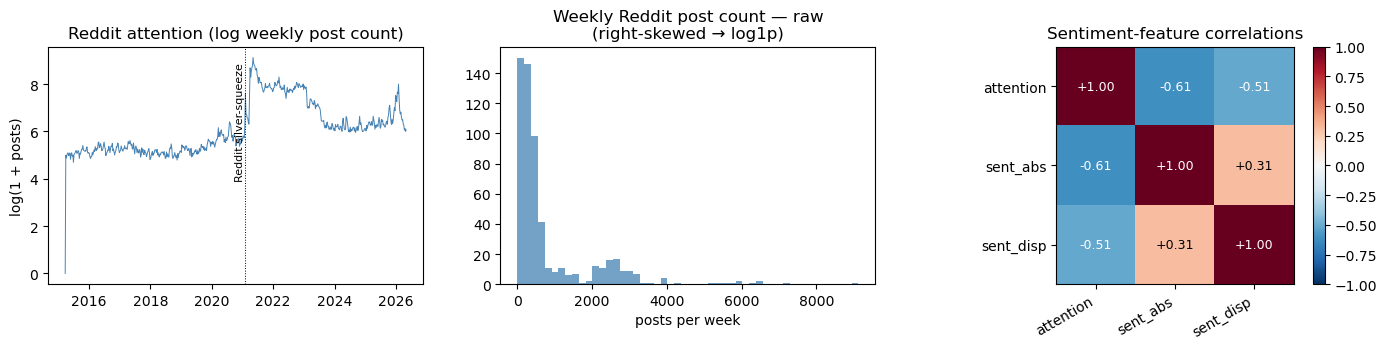

raw weekly post count: median=334  mean=846  max=9126   max/median = 27.4x
Note: the Feb-2021 silver-squeeze week sits in the *train* sample — this is a motivating example, not test-period evidence.


In [49]:
# 5b -- Sentiment-feature EDA: attention time series with the 2021 squeeze annotated,
# raw-count distribution that motivates log1p, and the 3-feature correlation matrix
# that explains the combined-rung redundancy in 01_har §5.
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))

# (1) attention time series -- unlagged, the actual Reddit history
att = sent_w['reddit_attention']
ax[0].plot(att.index, att, color='steelblue', lw=0.7)
ax[0].axvline(pd.Timestamp('2021-02-05'), color='black', ls=':', lw=0.7)
ax[0].text(pd.Timestamp('2021-02-05'), att.max() * 0.98,
           'Reddit silver-squeeze', fontsize=8, ha='right', rotation=90, va='top')
ax[0].set_title('Reddit attention (log weekly post count)')
ax[0].set_ylabel('log(1 + posts)')

# (2) raw weekly post-count distribution -- the right-skew justifying log1p
raw_counts = np.expm1(sent_w['reddit_attention'])
ax[1].hist(raw_counts.dropna(), bins=50, color='steelblue', alpha=0.75)
ax[1].set_title('Weekly Reddit post count — raw\n(right-skewed → log1p)')
ax[1].set_xlabel('posts per week')

# (3) sentiment-feature correlations on the sample where all three exist
sent_corr = frame[FEATS_SENT].dropna().corr()
im = ax[2].imshow(sent_corr, vmin=-1, vmax=1, cmap='RdBu_r')
labels = [c.replace('reddit_', '').replace('_lag1', '') for c in FEATS_SENT]
ax[2].set_xticks(range(3)); ax[2].set_yticks(range(3))
ax[2].set_xticklabels(labels, rotation=30, ha='right'); ax[2].set_yticklabels(labels)
for i in range(3):
    for j in range(3):
        ax[2].text(j, i, f'{sent_corr.iloc[i, j]:+.2f}', ha='center', va='center',
                   color='white' if abs(sent_corr.iloc[i, j]) > 0.5 else 'black',
                   fontsize=9)
ax[2].set_title('Sentiment-feature correlations')
fig.colorbar(im, ax=ax[2], fraction=0.04)

plt.tight_layout(); plt.show()

print(f"raw weekly post count: median={raw_counts.median():.0f}  "
      f"mean={raw_counts.mean():.0f}  max={raw_counts.max():.0f}   "
      f"max/median = {raw_counts.max()/raw_counts.median():.1f}x")
print('Note: the Feb-2021 silver-squeeze week sits in the *train* sample — this is a '
      'motivating example, not test-period evidence.')